# Teaching Machines to Notice the Unexpected
## LSTM-Based Anomaly Detection in Industrial Sensor Data

**Tutorial Author:** Ameer Hamza  
**Course:** Machine Learning and Neural Networks  
**Dataset:** SKAB, Skoltech Anomaly Benchmark (Katser & Kozitsin, 2020)  
**GitHub:** https://github.com/mh25afc/LSTM_SKAB_AnomalyDetection

---

| | |
|---|---|
| **Technique** | Long Short-Term Memory (LSTM) Neural Network |
| **Task** | Time-Series Anomaly Detection |
| **Dataset** | SKAB v0.9 — Industrial water pump sensor data |
| **Anomaly Method** | Prediction error thresholding (MAE + 3σ rule) |
| **Key Metrics** | Precision, Recall, F1-Score |

---
## Section 1: Introduction & Motivation

### 1.1 Why Anomaly Detection Matters

Every industrial system  a water pump, a turbine, a server rack  produces a continuous stream of sensor readings: temperature, pressure, vibration, flow rate. Under normal operation, these readings follow predictable temporal patterns. An anomaly is any point in time where the system deviates from its expected behaviour.

Catching anomalies early is critical:

- **Industrial machinery**: A subtle change in vibration can signal bearing failure hours before a catastrophic breakdown.
- **Power grids**: An unusual voltage spike may indicate a fault developing in a transformer.
- **Medical devices**: An irregular heartbeat pattern caught early can save a life.

Traditional rule-based systems (e.g. *"alert if pressure > 5 bar"*) are fragile. They require human experts to define every threshold manually, and they fail entirely against novel, previously unseen fault types. Machine learning specifically deep learning on sequences  offers a fundamentally better approach.

### 1.2 Why Time-Series Data is Hard

Standard machine learning models (decision trees, SVMs, MLPs) treat each data point as **independent**. But sensor readings are not independent the reading at time $t$ is strongly influenced by what happened at $t-1$, $t-2$, and so on.

Consider a pump running at steady state for 10 minutes, then suddenly experiencing a valve fault. The anomaly is not just about the value at a single timestep it is about the **break in the temporal pattern**. A model that ignores the sequence context will miss this entirely.

This is the core challenge of time-series anomaly detection: **the model must learn what normal looks like over time**, not just at a single moment.

### 1.3 Why LSTMs?

Recurrent Neural Networks (RNNs) were designed to process sequences. But early RNNs suffered a fundamental training problem — the **vanishing gradient problem**  which prevented them from learning long-range dependencies. Long Short-Term Memory networks (LSTMs), introduced by Hochreiter & Schmidhuber (1997), solve this with a gating mechanism that controls what information is remembered, forgotten, and passed forward.

For anomaly detection, the LSTM strategy is elegant:

> **Train the LSTM on normal data only. Then, when it sees an anomaly, its prediction error will spike because the anomaly breaks the temporal pattern it learned.**

This tutorial teaches you exactly how this works, step by step.

### 1.4 What You Will Learn

By the end of this tutorial, you will be able to:

1. Explain the vanishing gradient problem and how LSTM gates solve it
2. Build and train an LSTM in Keras for time-series prediction
3. Use reconstruction error as an anomaly signal with a statistical threshold
4. Evaluate anomaly detection using Precision, Recall, and F1-Score
5. Critically analyse where and why the model fails
6. Apply this pipeline to any multivariate sensor dataset



---
## Section 2 : Installing and Importing Libraries

In [ ]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os
import glob
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report)

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, RepeatVector, TimeDistributed
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Colourblind-friendly palette (Wong, 2011)
# Safe for deuteranopia, protanopia, and tritanopia
CB = {
    'blue'   : '#0072B2',
    'orange' : '#E69F00',
    'green'  : '#009E73',
    'red'    : '#D55E00',
    'purple' : '#CC79A7',
    'skyblue': '#56B4E9',
    'yellow' : '#F0E442',
    'black'  : '#000000'
}

plt.rcParams.update({
    'font.size'     : 12,
    'figure.dpi'    : 120,
    'axes.spines.top'   : False,
    'axes.spines.right' : False
})


---
## Section 3: The Dataset: SKAB (Skoltech Anomaly Benchmark)

### 3.1 What is SKAB?

SKAB (Katser & Kozitsin, 2020) is a real-world industrial anomaly detection benchmark collected at the Skolkovo Institute of Science and Technology (Skoltech), Russia. The testbed is a **water circulation system**  a physical pump-and-pipe rig instrumented with 8 sensors.

Researchers deliberately introduced physical faults into the system and recorded exactly when each fault occurred. This gives us something invaluable for a tutorial: **ground truth anomaly labels** tied to real, physically meaningful events.

### 3.2 The Physical Testbed

The SKAB testbed consists of:
- A water pump and pipe circuit
- A control system that regulates flow
- 8 sensors recording at 1-second intervals

Anomalies were physically induced, including:
- **Partial valve closures** : restricting water flow
- **Connecting shaft imbalance** : mechanical vibration fault
- **Reduced motor power** : electrical fault
- **Cavitation** : bubble formation disrupting flow

### 3.3 Dataset Structure

| Property | Detail |
|---|---|
| **Source** | Kaggle |
| **Files** | 35 individual CSV experiment files |
| **Sampling rate** | 1 reading per second |
| **Sensor channels** | 8 (accelerometer x/y/z, pressure, flow rate, motor voltage/current, water temperature) |
| **Anomaly labels** | `anomaly` column: 0 = normal, 1 = anomaly |
| **Anomaly types** | Point anomalies (sudden spikes) and collective anomalies (sustained deviations) |

### 3.4 Why SKAB for this Tutorial?

SKAB is ideal for teaching LSTM anomaly detection for three reasons:

1. **Real, not synthetic** : the anomalies were physically induced in a real system. The signal patterns are genuine, not artificially injected noise.
2. **Multiple channels** : 8 sensors give us multivariate time-series, which is how most real industrial problems look.
3. **Ground truth labels** : we can quantitatively evaluate our detector using Precision, Recall, and F1-Score against the known anomaly windows.

### 3.5 Loading the Data

Download SKAB from Kaggle:
```
kaggle datasets download -d yuriykatser/skoltech-anomaly-benchmark-skab
unzip skoltech-anomaly-benchmark-skab.zip -d skab_data
```
Or download manually from: https://www.kaggle.com/datasets/yuriykatser/skoltech-anomaly-benchmark-skab

The dataset contains multiple experiment files. We will load and concatenate them, then use one file for detailed visualisation.

In [ ]:
# Load all SKAB experiment files
# Update SKAB_PATH to where you extracted the dataset
SKAB_PATH = './skab_data/'

!kaggle datasets download -d yuriykatser/skoltech-anomaly-benchmark-skab
!unzip skoltech-anomaly-benchmark-skab.zip -d skab_data
# Sensor column names (8 channels)
SENSOR_COLS = [
    'Accelerometer1RMS',   # Accelerometer axis 1 (vibration)
    'Accelerometer2RMS',   # Accelerometer axis 2 (vibration)
    'Current',             # Motor current (Amps)
    'Pressure',            # Water pressure (bar)
    'Temperature',         # Water temperature (°C)
    'Thermocouple',        # Thermocouple temperature (°C)
    'Voltage',             # Motor supply voltage (V)
    'Volume Flow RateRMS'  # Water flow rate
]
TARGET_COL = 'anomaly'

def load_skab_files(base_path):
    """
    Load all SKAB CSV files from experiment subdirectories.
    Returns a concatenated DataFrame with a file_id column.
    """
    all_dfs = []
    csv_files = glob.glob(os.path.join(base_path, '**', '*.csv'), recursive=True)
    csv_files = [f for f in csv_files if 'all' not in f.lower()]  # skip summary files

    for i, fpath in enumerate(sorted(csv_files)):
        df = pd.read_csv(fpath, sep=';', index_col='datetime',
                         parse_dates=True, infer_datetime_format=True)
        df['file_id'] = i
        df['file_name'] = os.path.basename(fpath)
        all_dfs.append(df)

    combined = pd.concat(all_dfs, ignore_index=True)
    return combined, csv_files

df_all, file_list = load_skab_files(SKAB_PATH)

print(f"Files loaded        : {len(file_list)}")
print(f"Total samples       : {len(df_all):,}")
print(f"Sensor channels     : {SENSOR_COLS}")
print(f"\nColumn list         : {list(df_all.columns)}")
print(f"\nAnomaly distribution:")
print(df_all[TARGET_COL].value_counts())
print(f"Anomaly rate        : {df_all[TARGET_COL].mean()*100:.2f}%")

Dataset URL: https://www.kaggle.com/datasets/yuriykatser/skoltech-anomaly-benchmark-skab
License(s): GNU Affero General Public License 3.0
100% 1.24M/1.24M [00:01<00:00, 1.24MB/s]

Archive:  skoltech-anomaly-benchmark-skab.zip
  inflating: skab_data/SKAB/anomaly-free/anomaly-free.csv  
  inflating: skab_data/SKAB/other/11.csv  
  inflating: skab_data/SKAB/other/12.csv  
  inflating: skab_data/SKAB/other/13.csv  
  inflating: skab_data/SKAB/other/14.csv  
  inflating: skab_data/SKAB/other/15.csv  
  inflating: skab_data/SKAB/other/16.csv  
  inflating: skab_data/SKAB/other/17.csv  
  inflating: skab_data/SKAB/other/18.csv  
  inflating: skab_data/SKAB/other/19.csv  
  inflating: skab_data/SKAB/other/20.csv  
  inflating: skab_data/SKAB/other/21.csv  
  inflating: skab_data/SKAB/other/22.csv  
  inflating: skab_data/SKAB/other/23.csv  
  inflating: skab_data/SKAB/other/9.csv  
  inflating: skab_data/SKAB/valve1/0.csv  
  inflating: skab_data/SKAB/valve1/1.csv  
  inflating: skab_data/SKA

In [ ]:
# Preview the data
print("First 5 rows of combined SKAB dataset:")
print(df_all[SENSOR_COLS + [TARGET_COL]].head())
print(f"\nData types:\n{df_all[SENSOR_COLS + [TARGET_COL]].dtypes}")
print(f"\nMissing values per column:")
print(df_all[SENSOR_COLS + [TARGET_COL]].isnull().sum())

First 5 rows of combined SKAB dataset:
   Accelerometer1RMS  Accelerometer2RMS  Current  Pressure  Temperature  \
0           0.206030           0.277924  1.81019  0.382638      90.1740   
1           0.204366           0.275727  2.66317 -0.273216      90.2836   
2           0.206103           0.278526  2.63758  0.382638      89.8666   
3           0.204775           0.276948  2.32851  0.382638      90.2192   
4           0.206052           0.278141  2.53422  0.382638      90.1449   

   Thermocouple  Voltage  Volume Flow RateRMS  anomaly  
0       26.7760  228.208              121.664      NaN  
1       26.7760  227.245              122.000      NaN  
2       26.7821  237.872              122.000      NaN  
3       26.7773  230.422              121.338      NaN  
4       26.7773  219.454              121.664      NaN  

Data types:
Accelerometer1RMS      float64
Accelerometer2RMS      float64
Current                float64
Pressure               float64
Temperature            float64


### 3.6 Selecting a Representative Experiment File

For detailed visualisation and model training, we will work with a single experiment file that contains a clear mix of normal operation followed by induced anomalies. This allows us to see the LSTM's behaviour in context normal prediction, then error spike at the fault.

In [ ]:
# Load a single representative experiment file
# We choose file_id 5 (experiment with valve closure anomaly).
# You can change this to explore other experiments.
SELECTED_FILE_ID = 5
df = df_all[df_all['file_id'] == SELECTED_FILE_ID].copy()
df = df[SENSOR_COLS + [TARGET_COL]].reset_index(drop=True)

print(f"Selected experiment file: {file_list[SELECTED_FILE_ID]}")
print(f"Total timesteps    : {len(df):,}")
print(f"Normal timesteps   : {(df[TARGET_COL]==0).sum():,}")
print(f"Anomaly timesteps  : {(df[TARGET_COL]==1).sum():,}")
print(f"Anomaly rate       : {df[TARGET_COL].mean()*100:.2f}%")
print(f"\nDescriptive statistics:")
df[SENSOR_COLS].describe().round(3)

Selected experiment file: ./skab_data/SKAB/valve1/13.csv
Total timesteps    : 1,147
Normal timesteps   : 746
Anomaly timesteps  : 401
Anomaly rate       : 34.96%

Descriptive statistics:


,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS
count,1147.000,1147.000,1147.000,1147.000,1147.000,1147.000,1147.000,1147.000
mean,0.343,0.397,2.437,0.114,88.654,29.568,228.782,126.734
std,0.191,0.197,0.457,0.257,0.317,0.053,10.413,0.673
min,0.191,0.249,0.888,-0.929,87.890,29.424,202.335,124.644
25%,0.210,0.262,2.177,0.055,88.437,29.540,223.414,126.321
50%,0.213,0.264,2.553,0.055,88.631,29.574,228.860,127.000
75%,0.630,0.692,2.744,0.383,88.912,29.610,234.190,127.000
max,0.659,0.735,3.207,1.038,89.384,29.659,252.171,128.680


### 3.7 Exploratory Data Analysis (EDA)

Before building any model, we must understand the data. Three visualisations help here:

1. **All sensor channels over time** : with anomaly windows highlighted
2. **Signal distributions by class** : do anomalies shift the signal statistics?
3. **Correlation heatmap** : which sensors are related?

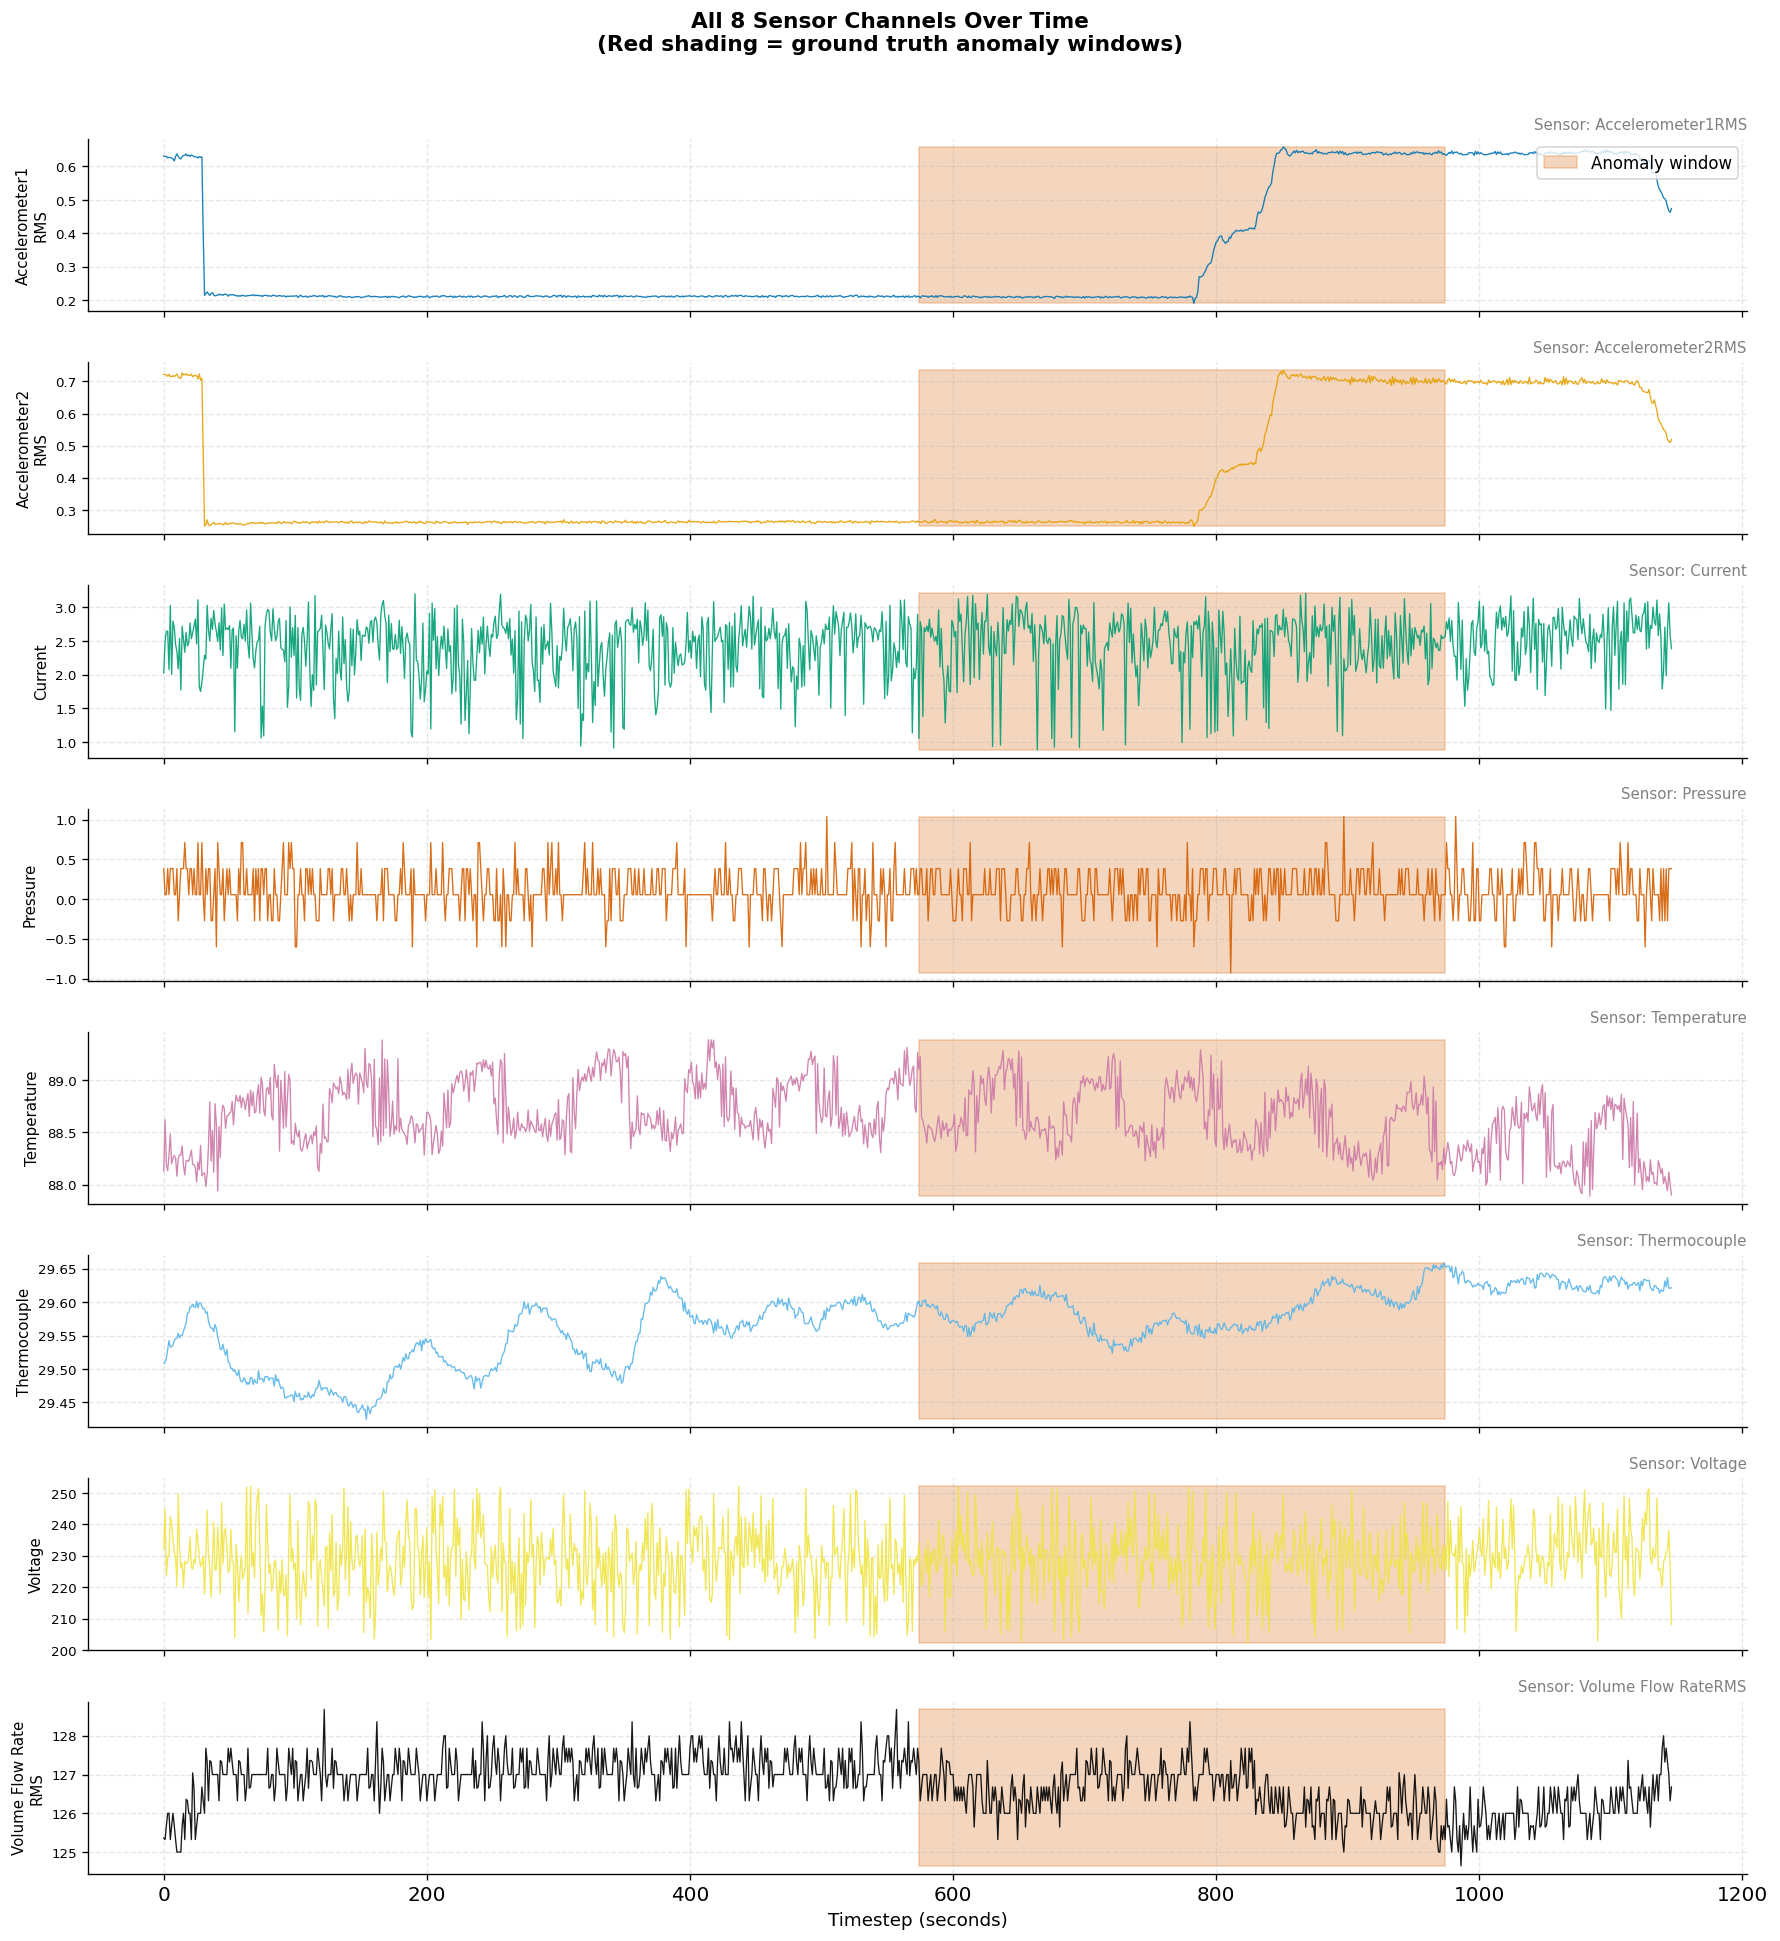

In [ ]:
# Figure 1: All sensor channels with anomaly overlay
# This is the most important EDA plot  it shows the temporal structure
# of the data and where anomalies fall in time.

anomaly_mask = df[TARGET_COL] == 1
time_idx = np.arange(len(df))

fig, axes = plt.subplots(len(SENSOR_COLS), 1, figsize=(15, 16), sharex=True)

colors = list(CB.values())[:len(SENSOR_COLS)]

for i, (col, ax) in enumerate(zip(SENSOR_COLS, axes)):
    # Plot the sensor signal
    ax.plot(time_idx, df[col].values,
            color=colors[i], linewidth=0.8, alpha=0.9)

    # Shade anomaly windows in light red
    ax.fill_between(time_idx,
                    df[col].min(), df[col].max(),
                    where=anomaly_mask,
                    alpha=0.25, color=CB['red'],
                    label='Anomaly window' if i == 0 else '')

    ax.set_ylabel(col.replace('RMS', '\nRMS'), fontsize=9)
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(True, alpha=0.3, linestyle='--')

    # Add alt text description as axis title (accessibility)
    ax.set_title(f'Sensor: {col}', fontsize=9, loc='right', color='grey')

axes[-1].set_xlabel('Timestep (seconds)', fontsize=11)
axes[0].legend(loc='upper right', fontsize=10)

fig.suptitle(
    'All 8 Sensor Channels Over Time\n'
    '(Red shading = ground truth anomaly windows)',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('fig1_sensor_channels.png', bbox_inches='tight', dpi=120)
# Alt text: Bar chart showing 8 sensor time series. Red shaded regions mark ground truth anomaly windows.
plt.show()


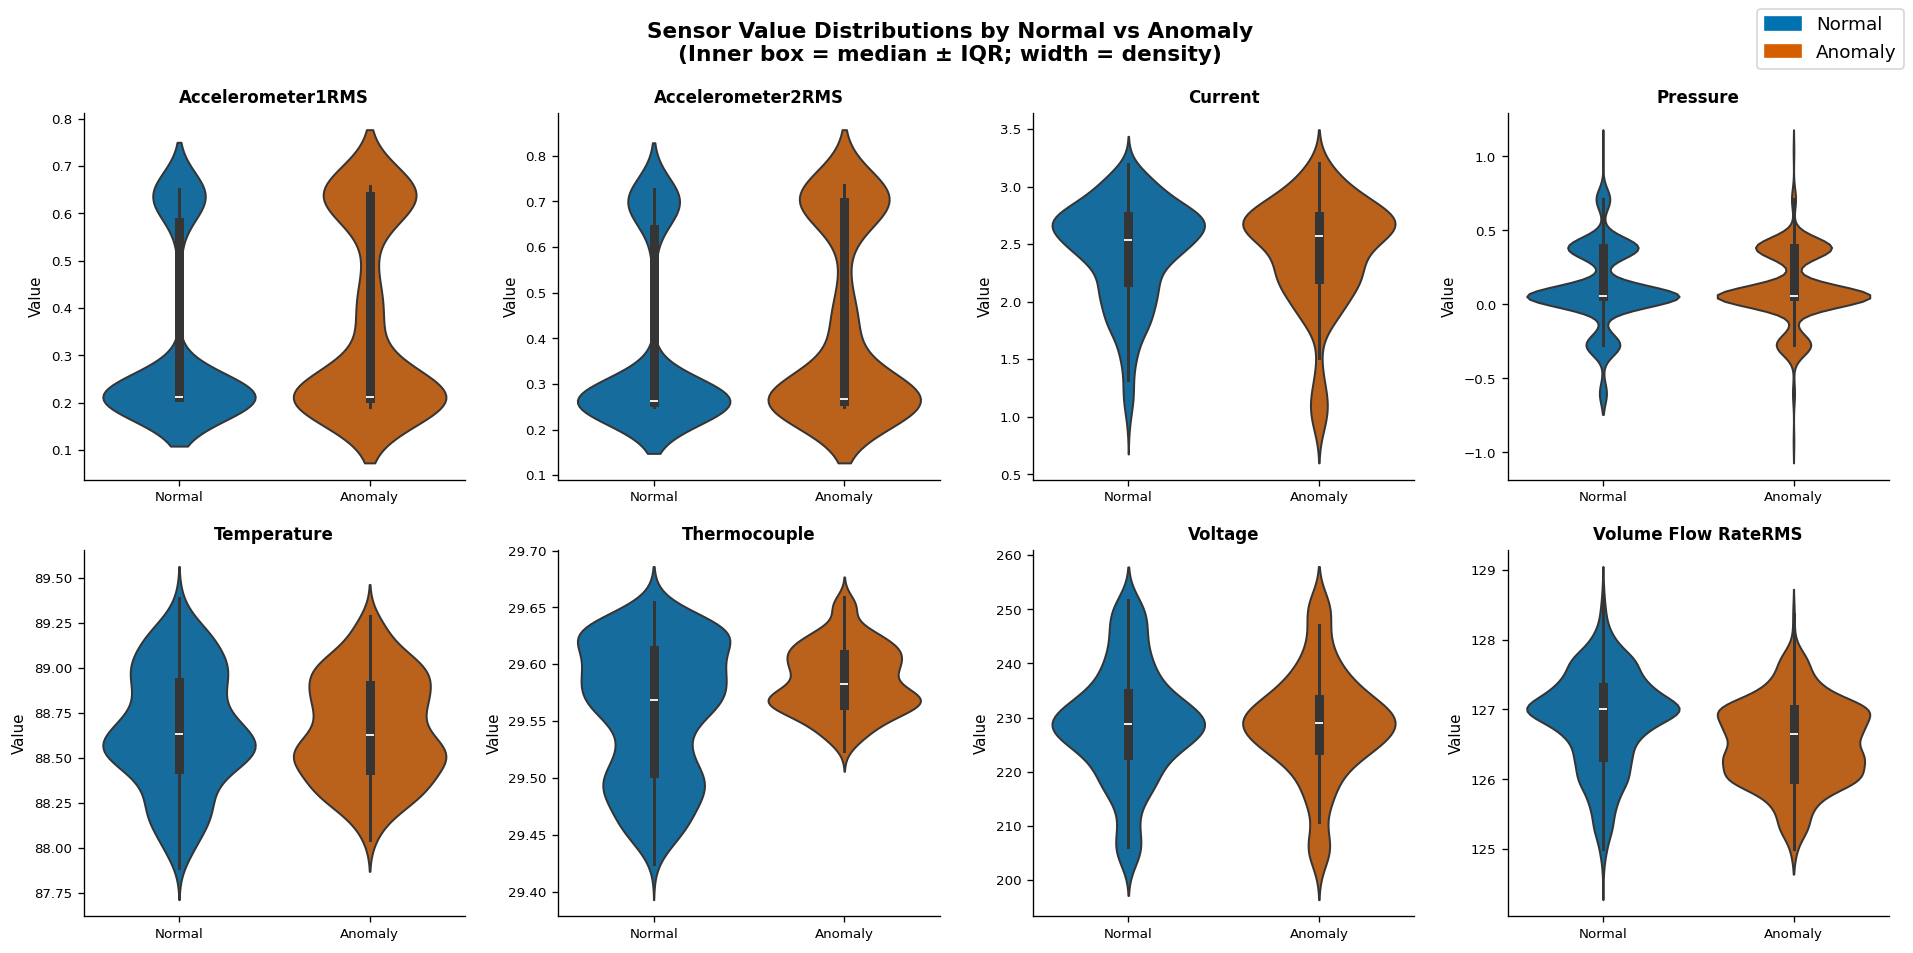

In [ ]:
# Figure 2: Signal distributions by Normal vs Anomaly
# Do anomalies shift sensor statistics? Violin plots show the full distribution
# shape, not just summary statistics.

df_melt = df[SENSOR_COLS + [TARGET_COL]].copy()
df_melt[TARGET_COL] = df_melt[TARGET_COL].map({0: 'Normal', 1: 'Anomaly'})
df_melt = df_melt.melt(id_vars=TARGET_COL, var_name='Sensor', value_name='Value')

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

palette = {'Normal': CB['blue'], 'Anomaly': CB['red']}

for i, col in enumerate(SENSOR_COLS):
    subset = df_melt[df_melt['Sensor'] == col]
    sns.violinplot(
        data=subset, x=TARGET_COL, y='Value',
        palette=palette, ax=axes[i],
        inner='box', linewidth=1.2
    )
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Value', fontsize=9)
    axes[i].tick_params(labelsize=8)

# Legend
normal_patch = mpatches.Patch(color=CB['blue'], label='Normal')
anomaly_patch = mpatches.Patch(color=CB['red'], label='Anomaly')
fig.legend(handles=[normal_patch, anomaly_patch],
           loc='upper right', fontsize=11, frameon=True)

fig.suptitle(
    'Sensor Value Distributions by Normal vs Anomaly\n'
    '(Inner box = median ± IQR; width = density)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('fig2_distributions.png', bbox_inches='tight', dpi=120)
plt.show()


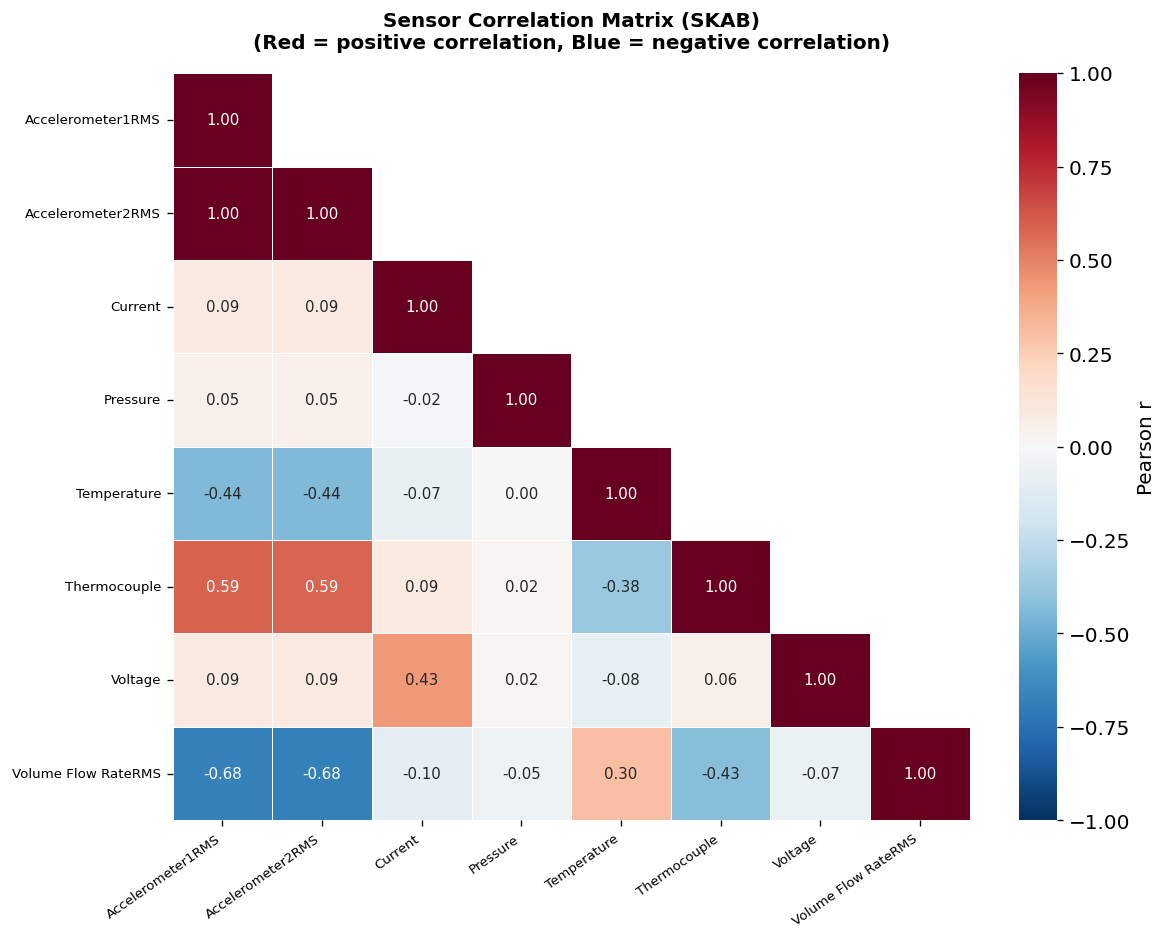


Top 3 most positively correlated sensor pairs:
Accelerometer2RMS  Accelerometer1RMS    0.999010
Thermocouple       Accelerometer1RMS    0.586892
                   Accelerometer2RMS    0.585696
dtype: float64

Top 3 most negatively correlated sensor pairs:
Temperature          Accelerometer1RMS   -0.440369
Volume Flow RateRMS  Accelerometer1RMS   -0.675542
                     Accelerometer2RMS   -0.680493
dtype: float64


In [ ]:
# Figure 3: Sensor correlation heatmap
# Understanding which sensors are correlated helps interpret model behaviour.
# Highly correlated sensors will both spike together during anomalies.

corr = df[SENSOR_COLS].corr()

# Use a mask for the upper triangle (avoid redundancy)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr, mask=mask,
    annot=True, fmt='.2f', annot_kws={'size': 9},
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Pearson r'}
)
ax.set_title(
    'Sensor Correlation Matrix (SKAB)\n'
    '(Red = positive correlation, Blue = negative correlation)',
    fontsize=12, fontweight='bold', pad=15
)
# Rotate x-axis labels for readability
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

plt.tight_layout()
plt.savefig('fig3_correlation_heatmap.png', bbox_inches='tight', dpi=120)
plt.show()


# Print the two most correlated pairs
corr_pairs = (corr.where(np.tril(np.ones(corr.shape), k=-1).astype(bool))
              .stack().sort_values(ascending=False))
print("\nTop 3 most positively correlated sensor pairs:")
print(corr_pairs.head(3))
print("\nTop 3 most negatively correlated sensor pairs:")
print(corr_pairs.tail(3))

---
## Section 4: How LSTMs Work: The Theory

### 4.1 The Vanishing Gradient Problem

Before LSTMs, Recurrent Neural Networks (RNNs) were the standard approach for sequential data. A vanilla RNN processes one timestep at a time, passing a hidden state $h_t$ forward:

$$h_t = \tanh(W_h h_{t-1} + W_x x_t + b)$$

During training, gradients are backpropagated through time (BPTT). For a sequence of length $T$, the gradient at an early timestep involves multiplying gradients from all subsequent timesteps:

$$\frac{\partial L}{\partial h_1} = \frac{\partial L}{\partial h_T} \prod_{t=2}^{T} \frac{\partial h_t}{\partial h_{t-1}}$$

If these gradients are small (< 1), this product **exponentially shrinks to zero** the vanishing gradient problem. The network effectively forgets what happened more than a few timesteps ago. For anomaly detection, where context over 30–100 timesteps matters, this is fatal.

> **Key insight:** A vanilla RNN cannot reliably learn that a valve was closed 45 seconds ago and use that context to classify a current reading as anomalous.

### 4.2 LSTM Gates The Solution

Hochreiter & Schmidhuber (1997) introduced the LSTM cell, which adds a **cell state** $c_t$ a long-term memory lane alongside the hidden state $h_t$. Three learnable gates control what flows in and out:

#### Forget Gate What to discard from long-term memory
$$f_t = \sigma(W_f [h_{t-1}, x_t] + b_f)$$
Output ∈ (0,1). Values near 0 = forget; values near 1 = keep.

#### Input Gate What new information to store
$$i_t = \sigma(W_i [h_{t-1}, x_t] + b_i)$$
$$\tilde{c}_t = \tanh(W_c [h_{t-1}, x_t] + b_c)$$

#### Cell State Update Combining old memory with new information
$$c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t$$

#### Output Gate What to output from memory
$$o_t = \sigma(W_o [h_{t-1}, x_t] + b_o)$$
$$h_t = o_t \odot \tanh(c_t)$$

Where $\sigma$ = sigmoid function, $\odot$ = element-wise multiplication.

**Why does this solve vanishing gradients?**  
The cell state $c_t$ is updated through **addition**, not multiplication: $c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t$. Addition preserves gradient magnitude gradients can flow backward through the cell state without shrinking exponentially. This is the fundamental insight behind LSTMs.

### 4.3 LSTM for Anomaly Detection The Strategy

We use LSTMs for anomaly detection through a **prediction-error approach**:

1. **Train** the LSTM on normal (anomaly-free) data to predict the next timestep
2. **At test time**, run the model on both normal and anomalous data
3. **Compute** the Mean Absolute Error (MAE) between prediction and actual reading
4. **Threshold** the error: if MAE > threshold → flag as anomaly

The intuition: an LSTM trained on normal patterns will predict normal readings well (low error). When it encounters an anomaly a pattern it has never seen its prediction will be wrong (high error).

$$\text{MAE}_t = \frac{1}{N}\sum_{j=1}^{N} |x_{t,j} - \hat{x}_{t,j}|$$

Where $N$ = number of sensor channels, $x$ = actual value, $\hat{x}$ = predicted value.

The threshold is set statistically:
$$\text{threshold} = \mu_{\text{MAE}} + 3\sigma_{\text{MAE}}$$

Where $\mu$ and $\sigma$ are computed on the **training set errors only**  preventing data leakage from the test set.

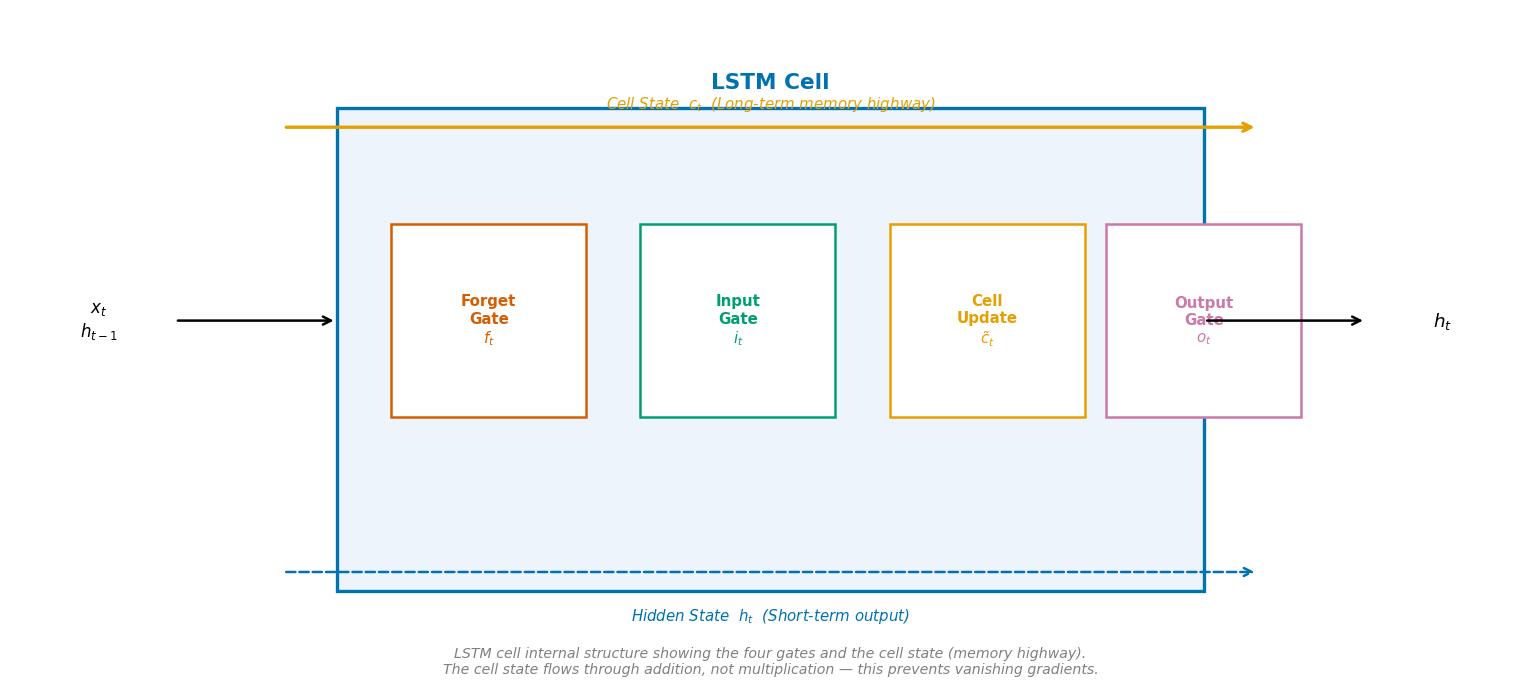

In [ ]:
# Figure 4: LSTM Architecture Diagram (schematic via matplotlib)
# A clean visual of the LSTM gate mechanism for teaching purposes

fig, ax = plt.subplots(figsize=(13, 6))
ax.set_xlim(0, 14)
ax.set_ylim(0, 7)
ax.axis('off')

# LSTM cell box
cell_box = plt.Rectangle((3, 1), 8, 5, linewidth=2,
                          edgecolor=CB['blue'], facecolor='#EEF4FB', zorder=1)
ax.add_patch(cell_box)
ax.text(7, 6.2, 'LSTM Cell', ha='center', fontsize=13,
        fontweight='bold', color=CB['blue'])

# Gate boxes
gate_info = [
    (3.5, 2.8, 'Forget\nGate\n$f_t$', CB['red']),
    (5.8, 2.8, 'Input\nGate\n$i_t$', CB['green']),
    (8.1, 2.8, 'Cell\nUpdate\n$\\tilde{c}_t$', CB['orange']),
    (10.1, 2.8, 'Output\nGate\n$o_t$', CB['purple']),
]
for (x, y, label, color) in gate_info:
    box = plt.Rectangle((x, y), 1.8, 2, linewidth=1.5,
                         edgecolor=color, facecolor='white', zorder=2)
    ax.add_patch(box)
    ax.text(x + 0.9, y + 1.0, label, ha='center', va='center',
            fontsize=9, color=color, fontweight='bold', zorder=3)

# Cell state arrow (top lane)
ax.annotate('', xy=(11.5, 5.8), xytext=(2.5, 5.8),
            arrowprops=dict(arrowstyle='->', color=CB['orange'], lw=2.0))
ax.text(7.0, 6.0, 'Cell State  $c_t$  (Long-term memory highway)',
        ha='center', fontsize=9, color=CB['orange'], style='italic')

# Hidden state arrow (bottom)
ax.annotate('', xy=(11.5, 1.2), xytext=(2.5, 1.2),
            arrowprops=dict(arrowstyle='->', color=CB['blue'], lw=1.5,
                            linestyle='dashed'))
ax.text(7.0, 0.7, 'Hidden State  $h_t$  (Short-term output)',
        ha='center', fontsize=9, color=CB['blue'], style='italic')

# Input arrow
ax.annotate('', xy=(3.0, 3.8), xytext=(1.5, 3.8),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
ax.text(0.8, 3.8, '$x_t$\n$h_{t-1}$', ha='center', va='center', fontsize=10)

# Output arrow
ax.annotate('', xy=(12.5, 3.8), xytext=(11.0, 3.8),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
ax.text(13.2, 3.8, '$h_t$', ha='center', va='center', fontsize=11)

# Labels
ax.text(7, 0.15,
        'LSTM cell internal structure showing the four gates and the cell state (memory highway).\n'
        'The cell state flows through addition, not multiplication — this prevents vanishing gradients.',
        ha='center', fontsize=8.5, color='grey', style='italic')

plt.tight_layout()
plt.savefig('fig4_lstm_diagram.png', bbox_inches='tight', dpi=120)
plt.show()


---
## Section 5 : Data Preprocessing & Sliding Window Construction

### 5.1 Why Preprocessing Matters for LSTMs

LSTMs are sensitive to the scale of input values. If one sensor reads in the range [0, 1000] and another reads [0.001, 0.01], the network will effectively ignore the small-scale sensor its gradients will be negligible compared to the large-scale one. **MinMax normalisation** maps every sensor to [0, 1], giving each channel equal influence on the model.

**Critical rule fit the scaler on training data only.** If you fit on the full dataset (including the test set), information from future anomaly values leaks into the normalisation parameters. This inflates evaluation metrics and produces a model that would not generalise in production.

### 5.2 Train/Test Split Strategy

For anomaly detection, we split **temporally**  the first portion of the time series is used for training (normal operation only), and the remainder including the anomaly windows is used for testing. This mirrors real deployment: you train on historical normal data, then run the model on live data.

We train on the **normal (anomaly-free) portion only**. This is the key design choice the LSTM learns what normal looks like, so that deviations become detectable through high prediction error.

### 5.3 The Sliding Window

LSTMs require fixed-length input sequences. We use a **sliding window** of size `W = 30` timesteps:

- Input: sensor readings at timesteps $[t, t+1, ..., t+W-1]$ → shape: `(W, 8)`
- Target: sensor readings at timestep $t+W$ → shape: `(8,)`

The window slides one step at a time across the time series. This is a **many-to-one** prediction task: given the last 30 seconds, predict the next second. At test time, the prediction error at each timestep becomes our anomaly score.

**Why window size 30?** This corresponds to 30 seconds of sensor data long enough to capture meaningful temporal context (the LSTM can learn that a vibration spike followed by a pressure drop is a precursor to a fault), but short enough to be computationally efficient.

In [ ]:
# Identify normal vs anomaly regions
normal_df = df[df[TARGET_COL] == 0][SENSOR_COLS].copy()
full_df   = df[SENSOR_COLS].copy()

print(f'Total timesteps      : {len(df):,}')
print(f'Normal timesteps     : {len(normal_df):,}')
print(f'Anomaly timesteps    : {len(df) - len(normal_df):,}')

# Step 2: Temporal train/test split
# Use 70% of NORMAL data for training, rest for evaluation context.
# Test set = full sequence (normal + anomaly) so we can evaluate detection.
TRAIN_RATIO = 0.70
WINDOW_SIZE = 30

n_train = int(len(normal_df) * TRAIN_RATIO)
train_raw = normal_df.iloc[:n_train].values
test_raw  = full_df.values

print(f'\nWindow size          : {WINDOW_SIZE} timesteps')
print(f'Training samples     : {len(train_raw):,} (normal only)')
print(f'Test samples         : {len(test_raw):,} (full sequence)')

# MinMax normalization fit on train ONLY
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_raw)
test_scaled  = scaler.transform(test_raw)

print(f'\nAfter scaling train range: [{train_scaled.min():.3f}, {train_scaled.max():.3f}]')
print(f'After scaling test range : [{test_scaled.min():.3f}, {test_scaled.max():.3f}]')


Total timesteps      : 1,147
Normal timesteps     : 746
Anomaly timesteps    : 401

Window size          : 30 timesteps
Training samples     : 522 (normal only)
Test samples         : 1,147 (full sequence)

After scaling train range: [0.000, 1.000]
After scaling test range : [-0.200, 1.094]


In [ ]:
# Temporal split + MinMax normalization
# Critical: scaler fitted on TRAINING data ONLY

TRAIN_RATIO = 0.70
WINDOW_SIZE = 30

n_train   = int(len(normal_df) * TRAIN_RATIO)
train_raw = normal_df.iloc[:n_train].values
test_raw  = full_df.values   # full sequence including anomalies

print(f'Window size          : {WINDOW_SIZE} timesteps (= 30 seconds)')
print(f'Training samples     : {len(train_raw):,}  (normal operation only)')
print(f'Test samples         : {len(test_raw):,}   (full sequence incl. anomalies)')

# MinMax scaling fit on train ONLY
scaler       = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_raw)  # fit + transform
test_scaled  = scaler.transform(test_raw)        # transform only — no leakage

print(f'\nAfter scaling train: [{train_scaled.min():.3f}, {train_scaled.max():.3f}]')
print(f'After scaling test : [{test_scaled.min():.3f}, {test_scaled.max():.3f}]')

Window size          : 30 timesteps (= 30 seconds)
Training samples     : 522  (normal operation only)
Test samples         : 1,147   (full sequence incl. anomalies)

After scaling train: [0.000, 1.000]
After scaling test : [-0.200, 1.094]


In [ ]:
# Sliding window construction
def create_windows(data, window_size):
    """
    Create sliding windows for many-to-one LSTM prediction.

    Args:
        data       : np.ndarray of shape (timesteps, n_features)
        window_size: number of timesteps per input window

    Returns:
        X : np.ndarray of shape (n_windows, window_size, n_features)
        y : np.ndarray of shape (n_windows, n_features)  [next timestep]
    """
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i : i + window_size])
        y.append(data[i + window_size])
    return np.array(X), np.array(y)

# Build training windows (from normal data only)
X_train, y_train = create_windows(train_scaled, WINDOW_SIZE)

# Build test windows (from full sequence)
X_test, y_test   = create_windows(test_scaled, WINDOW_SIZE)

# Align test labels with windows (label applies to the TARGET timestep)
test_labels = df[TARGET_COL].values[WINDOW_SIZE:]   # shift by window size

print(f'Training windows  : {X_train.shape}  →  X: (samples, timesteps, features)')
print(f'Training targets  : {y_train.shape}  →  y: (samples, features)')
print(f'Test windows      : {X_test.shape}')
print(f'Test targets      : {y_test.shape}')
print(f'Test labels       : {test_labels.shape}  (0=normal, 1=anomaly)')
print(f'\nAnomaly rate in test labels: {test_labels.mean()*100:.2f}%')

Training windows  : (492, 30, 8)  →  X: (samples, timesteps, features)
Training targets  : (492, 8)  →  y: (samples, features)
Test windows      : (1117, 30, 8)
Test targets      : (1117, 8)
Test labels       : (1117,)  (0=normal, 1=anomaly)

Anomaly rate in test labels: 35.90%


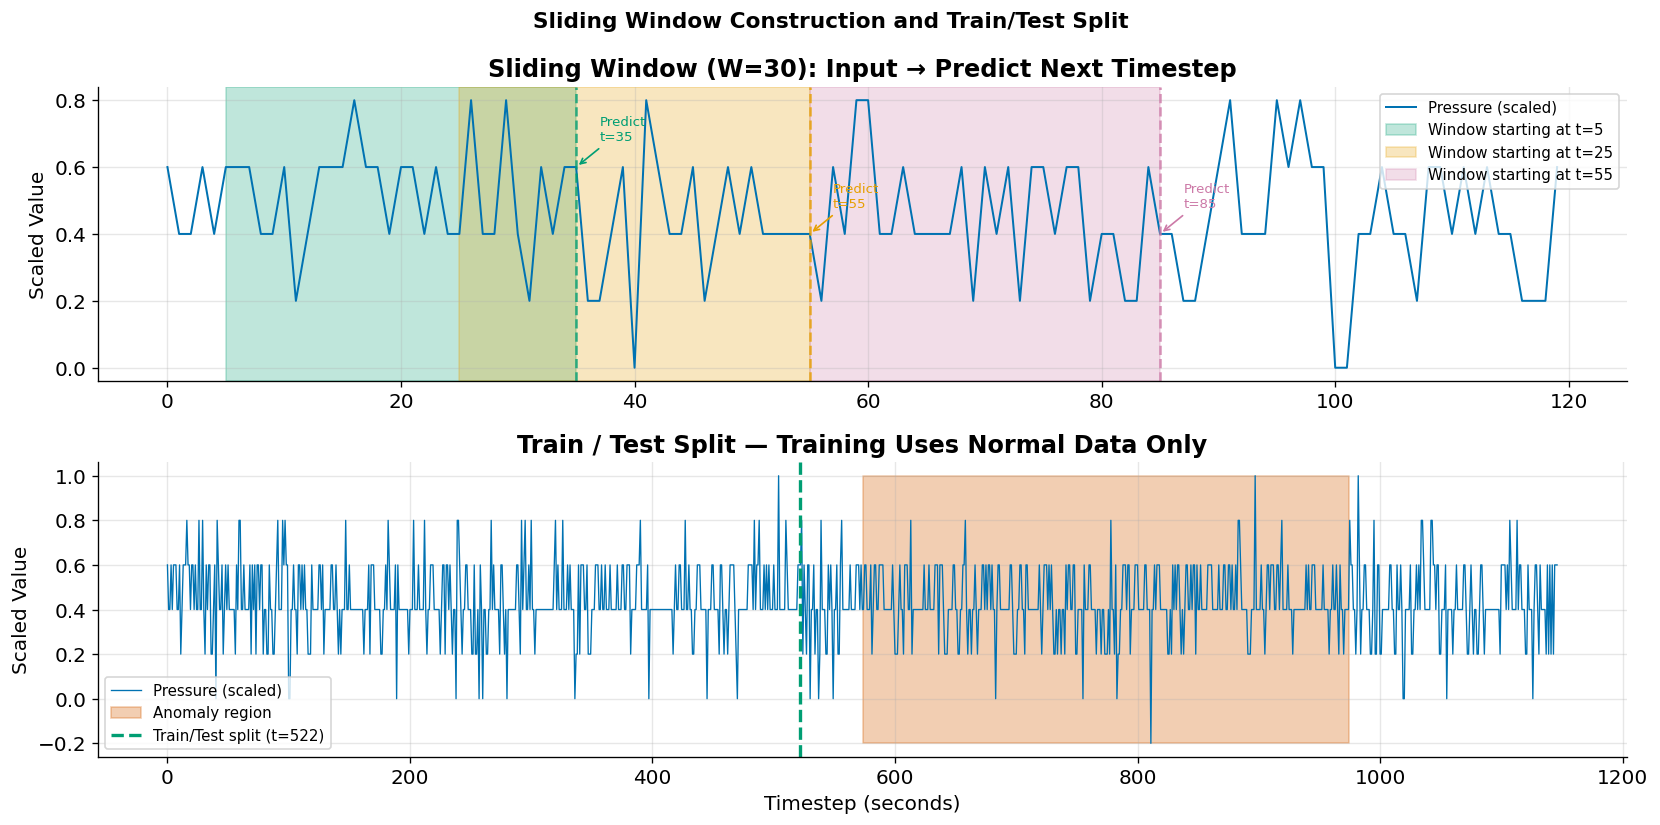

In [ ]:
# Figure 5: Sliding window concept visualization
# Teach the reader what a sliding window looks like on real sensor data

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# Top panel: one sensor channel with window overlay
sensor_viz = 'Pressure'
sensor_idx = SENSOR_COLS.index(sensor_viz)
signal = test_scaled[:120, sensor_idx]   # first 120 timesteps for clarity

axes[0].plot(signal, color=CB['blue'], linewidth=1.2, label=f'{sensor_viz} (scaled)')

# Highlight 3 example windows
window_starts = [5, 25, 55]
window_colors = [CB['green'], CB['orange'], CB['purple']]
for ws, wc in zip(window_starts, window_colors):
    axes[0].axvspan(ws, ws + WINDOW_SIZE, alpha=0.25, color=wc,
                    label=f'Window starting at t={ws}')
    axes[0].axvline(ws + WINDOW_SIZE, color=wc, linestyle='--',
                    linewidth=1.5, alpha=0.8)
    axes[0].annotate(f'Predict\nt={ws+WINDOW_SIZE}',
                     xy=(ws + WINDOW_SIZE, signal[ws + WINDOW_SIZE]),
                     xytext=(ws + WINDOW_SIZE + 2, signal[ws + WINDOW_SIZE] + 0.08),
                     fontsize=8, color=wc,
                     arrowprops=dict(arrowstyle='->', color=wc, lw=1.0))

axes[0].set_title(f'Sliding Window (W={WINDOW_SIZE}): Input → Predict Next Timestep',
                  fontweight='bold')
axes[0].set_ylabel('Scaled Value')
axes[0].legend(fontsize=9, loc='upper right')
axes[0].grid(True, alpha=0.3)

# Bottom panel: training vs test split overview on full Pressure signal
full_signal = test_scaled[:, sensor_idx]
anom = df[TARGET_COL].values

axes[1].plot(full_signal, color=CB['blue'], linewidth=0.8, label='Pressure (scaled)')
axes[1].fill_between(range(len(full_signal)),
                     full_signal.min(), full_signal.max(),
                     where=(anom == 1),
                     alpha=0.3, color=CB['red'], label='Anomaly region')
axes[1].axvline(n_train, color=CB['green'], linewidth=2,
                linestyle='--', label=f'Train/Test split (t={n_train})')
axes[1].set_title('Train / Test Split — Training Uses Normal Data Only',
                  fontweight='bold')
axes[1].set_xlabel('Timestep (seconds)')
axes[1].set_ylabel('Scaled Value')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

fig.suptitle('Sliding Window Construction and Train/Test Split',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_sliding_window.png', bbox_inches='tight', dpi=120)
plt.show()

---
## Section 6: Building and Training the LSTM

### 6.1 Model Architecture

We build a **stacked LSTM** with two LSTM layers followed by a Dense output layer. The architecture is designed to:

1. **First LSTM layer (64 units, `return_sequences=True`)**:  processes the 30-timestep input and passes a sequence of hidden states to the next layer. `return_sequences=True` means it outputs a hidden state at every timestep, not just the last.
2. **Dropout (20%)** : randomly zeroes 20% of LSTM outputs during training. This prevents the model from over-relying on specific neurons, improving generalisation to unseen data (Srivastava et al., 2014).
3. **Second LSTM layer (32 units, `return_sequences=False`)** : processes the sequence from layer 1 and produces a single context vector summarising the entire 30-timestep window.
4. **Dropout (20%)** : second regularisation stage.
5. **Dense output layer (8 units)** : predicts the 8 sensor values at the next timestep.

**Why two LSTM layers?** The first layer learns low-level temporal patterns (e.g., short-term oscillations in pressure). The second layer learns higher-level patterns over those longer trends and multi-sensor relationships that are more informative for anomaly detection.

### 6.2 Loss Function and Optimizer

- **Loss:** Mean Squared Error (MSE). We want to minimize the squared difference between predicted and actual sensor readings.
- **Optimiser:** Adam (Kingma & Ba, 2014). Adam adapts the learning rate per-parameter, which is well-suited to LSTM training where different gates update at different rates.

### 6.3 Early Stopping

Training stops when validation loss stops improving for 10 consecutive epochs (`patience=10`). The best weights are restored at the end. This prevents overfitting without requiring manual tuning of the number of epochs.

In [ ]:
# Build the stacked LSTM model
N_FEATURES = len(SENSOR_COLS)    # 8 sensor channels

def build_lstm_model(window_size, n_features,
                     lstm_units_1=64, lstm_units_2=32,
                     dropout_rate=0.20):
    """
    Stacked LSTM for multivariate time-series prediction.

    Architecture:
        Input  →  LSTM(64, return_seq=True)  →  Dropout(0.2)
               →  LSTM(32, return_seq=False) →  Dropout(0.2)
               →  Dense(8)
    """
    model = Sequential([
        # Layer 1: LSTM outputs sequence so layer 2 can see all timesteps
        LSTM(lstm_units_1,
             input_shape=(window_size, n_features),
             return_sequences=True,
             name='lstm_layer_1'),
        Dropout(dropout_rate, name='dropout_1'),

        # Layer 2: LSTM compresses sequence to single context vector
        LSTM(lstm_units_2,
             return_sequences=False,
             name='lstm_layer_2'),
        Dropout(dropout_rate, name='dropout_2'),

        # Output: predict next timestep for all 8 sensors
        Dense(n_features, name='output_layer')
    ], name='LSTM_AnomalyDetector')

    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )
    return model

model = build_lstm_model(WINDOW_SIZE, N_FEATURES)
model.summary()

total_params = model.count_params()
print(f'\nTotal trainable parameters: {total_params:,}')

Model: "LSTM_AnomalyDetector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_layer_1 (LSTM)             │ (None, 30, 64)         │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_layer_2 (LSTM)             │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 8)              │           264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,368 (122.53 KB)

 Trainable params: 31,368 (122.53 KB)

 Non-trainable params: 0 (0.00 B)


Total trainable parameters: 31,368


In [ ]:
# Train the model
EPOCHS    = 100   # max epochs Early Stopping will cut this short
BATCH     = 64
VAL_SPLIT = 0.15

callbacks = [
    EarlyStopping(
        monitor   = 'val_loss',
        patience  = 10,
        restore_best_weights = True,
        verbose   = 1
    ),
    ModelCheckpoint(
        filepath = 'best_lstm_model.keras',
        monitor  = 'val_loss',
        save_best_only = True,
        verbose  = 0
    )
]

print('Training LSTM on normal data only...')
print(f'  Training windows : {X_train.shape[0]:,}')
print(f'  Batch size       : {BATCH}')
print(f'  Max epochs       : {EPOCHS}')
print(f'  Early stopping   : patience=10 on val_loss')
print()

history = model.fit(
    X_train, y_train,
    epochs          = EPOCHS,
    batch_size      = BATCH,
    validation_split= VAL_SPLIT,
    callbacks       = callbacks,
    shuffle         = False,   # preserve temporal order within training data
    verbose         = 1
)

actual_epochs = len(history.history['loss'])
best_val_loss = min(history.history['val_loss'])
print(f'\n✓ Training complete.')
print(f'  Epochs run        : {actual_epochs}')
print(f'  Best val_loss     : {best_val_loss:.6f}')

Training LSTM on normal data only...
  Training windows : 492
  Batch size       : 64
  Max epochs       : 100
  Early stopping   : patience=10 on val_loss

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - loss: 0.2509 - mae: 0.4251 - val_loss: 0.1499 - val_mae: 0.3148
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0769 - mae: 0.2208 - val_loss: 0.0345 - val_mae: 0.1370
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0540 - mae: 0.1819 - val_loss: 0.0248 - val_mae: 0.1193
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0507 - mae: 0.1766 - val_loss: 0.0302 - val_mae: 0.1330
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0478 - mae: 0.1717 - val_loss: 0.0340 - val_mae: 0.1359
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0432 - mae: 0.1585 - val_loss: 0.0293 - val_mae: 0.1257
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0413 - mae: 0.1556 - val_loss: 0.0244 - val_mae: 0.1123
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━

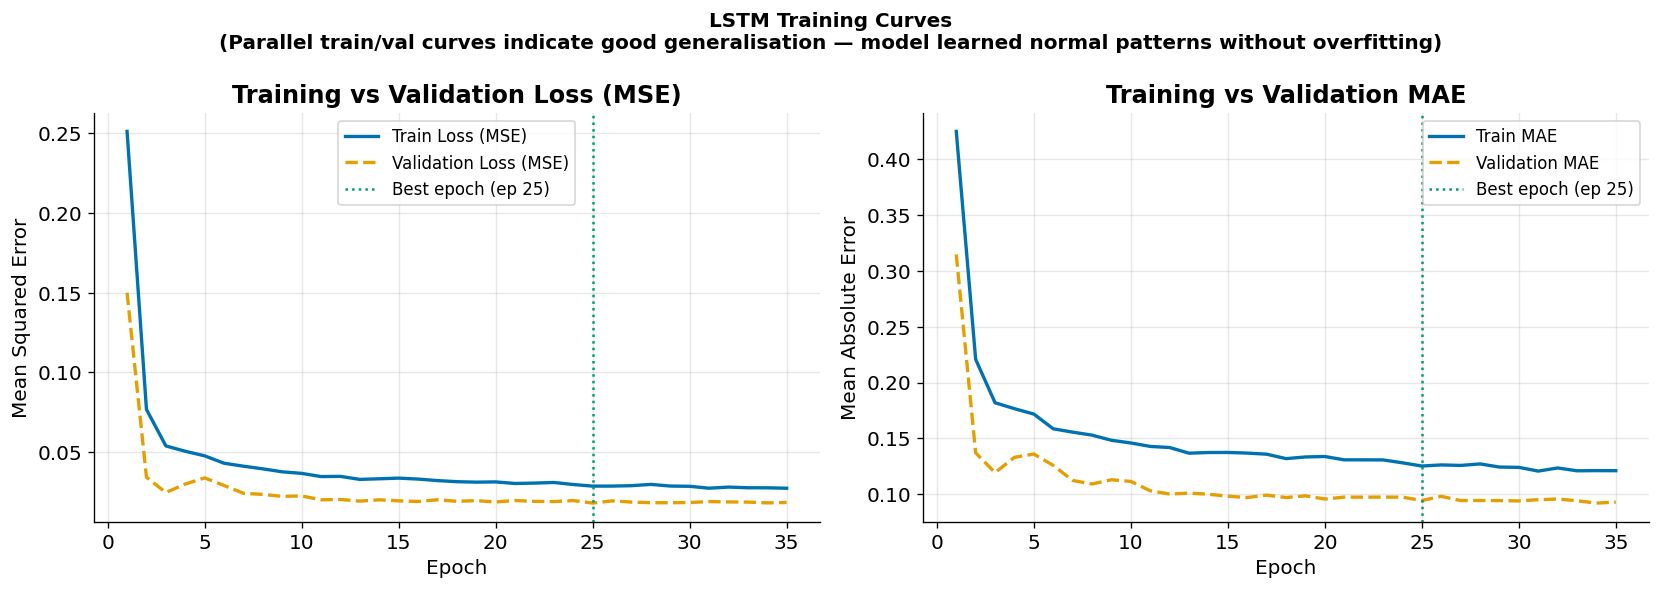

In [ ]:
# Figure 6: Training and Validation Loss Curves
# This is the primary diagnostic for training quality.
# Parallel curves = good generalisation. Diverging = overfitting.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, actual_epochs + 1)

#Left: MSE loss
axes[0].plot(epochs_range, history.history['loss'],
             color=CB['blue'], linewidth=2.0, label='Train Loss (MSE)')
axes[0].plot(epochs_range, history.history['val_loss'],
             color=CB['orange'], linewidth=2.0,
             linestyle='--', label='Validation Loss (MSE)')
best_ep = np.argmin(history.history['val_loss']) + 1
axes[0].axvline(best_ep, color=CB['green'], linewidth=1.5,
                linestyle=':', label=f'Best epoch (ep {best_ep})')
axes[0].set_title('Training vs Validation Loss (MSE)', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Mean Squared Error')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Right: MAE
axes[1].plot(epochs_range, history.history['mae'],
             color=CB['blue'], linewidth=2.0, label='Train MAE')
axes[1].plot(epochs_range, history.history['val_mae'],
             color=CB['orange'], linewidth=2.0,
             linestyle='--', label='Validation MAE')
axes[1].axvline(best_ep, color=CB['green'], linewidth=1.5,
                linestyle=':', label=f'Best epoch (ep {best_ep})')
axes[1].set_title('Training vs Validation MAE', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Mean Absolute Error')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

fig.suptitle('LSTM Training Curves\n'
             '(Parallel train/val curves indicate good generalisation — '
             'model learned normal patterns without overfitting)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_training_curves.png', bbox_inches='tight', dpi=120)
plt.show()


---
## Section 7: Anomaly Detection via Reconstruction Error

### 7.1 The Prediction Error Approach

The LSTM was trained to predict the next sensor reading given the last 30 seconds. Now we run it on the **full test sequence** (including anomaly windows) and measure how wrong it is at every timestep.

At each timestep $t$, the **anomaly score** is the Mean Absolute Error across all 8 sensor channels:

$$\text{score}_t = \frac{1}{8}\sum_{j=1}^{8} |x_{t,j} - \hat{x}_{t,j}|$$

Under normal operation, the score should be low the LSTM has seen this pattern before. When an anomaly occurs, the LSTM's prediction diverges from reality, causing a spike in the error score.

### 7.2 Setting the Anomaly Threshold

We use a **statistical threshold** based on the error distribution on the training set:

$$\text{threshold} = \mu_{\text{train}} + k \cdot \sigma_{\text{train}}$$

Where $k$ is a sensitivity multiplier. We use $k=3$ as the default (the 3-sigma rule), which covers 99.7% of a normal distribution. We will explore the effect of changing $k$ in Section 8.

**Why use training errors for the threshold?** The threshold must be set without looking at the test set. Using training errors ensures the threshold reflects the model's normal operating error not contaminated by the anomaly values we're trying to detect.

In [ ]:
# Compute prediction errors on training set (for threshold)
y_train_pred = model.predict(X_train, verbose=0)

# MAE per timestep across all 8 sensor channels
train_mae = np.mean(np.abs(y_train - y_train_pred), axis=1)

mu_train    = train_mae.mean()
sigma_train = train_mae.std()

# Default threshold: mean + 3 * std
K = 3.0
THRESHOLD = mu_train + K * sigma_train

print('** Training Error Statistics ***************************')
print(f'  Mean MAE (train)  : {mu_train:.6f}')
print(f'  Std  MAE (train)  : {sigma_train:.6f}')
print(f'  Threshold (k={K})  : {THRESHOLD:.6f}')
print(f'  Formula           : {mu_train:.4f} + {K} × {sigma_train:.4f}')

** Training Error Statistics ***************************
  Mean MAE (train)  : 0.096183
  Std  MAE (train)  : 0.034259
  Threshold (k=3.0)  : 0.198959
  Formula           : 0.0962 + 3.0 × 0.0343


In [ ]:
# Compute prediction errors on test set
y_test_pred = model.predict(X_test, verbose=0)

# MAE per timestep
test_mae = np.mean(np.abs(y_test - y_test_pred), axis=1)

# Binary anomaly predictions: 1 if error > threshold, else 0
y_pred_binary = (test_mae > THRESHOLD).astype(int)

print('** Test Error Statistics ******************************')
print(f'  Mean MAE (test)        : {test_mae.mean():.6f}')
print(f'  Max  MAE (test)        : {test_mae.max():.6f}')
print(f'  Threshold              : {THRESHOLD:.6f}')
print(f'  Flagged as anomaly     : {y_pred_binary.sum():,} timesteps')
print(f'  True anomaly timesteps : {test_labels.sum():,} timesteps')

** Test Error Statistics ******************************
  Mean MAE (test)        : 0.164755
  Max  MAE (test)        : 0.448930
  Threshold              : 0.198959
  Flagged as anomaly     : 328 timesteps
  True anomaly timesteps : 401.0 timesteps


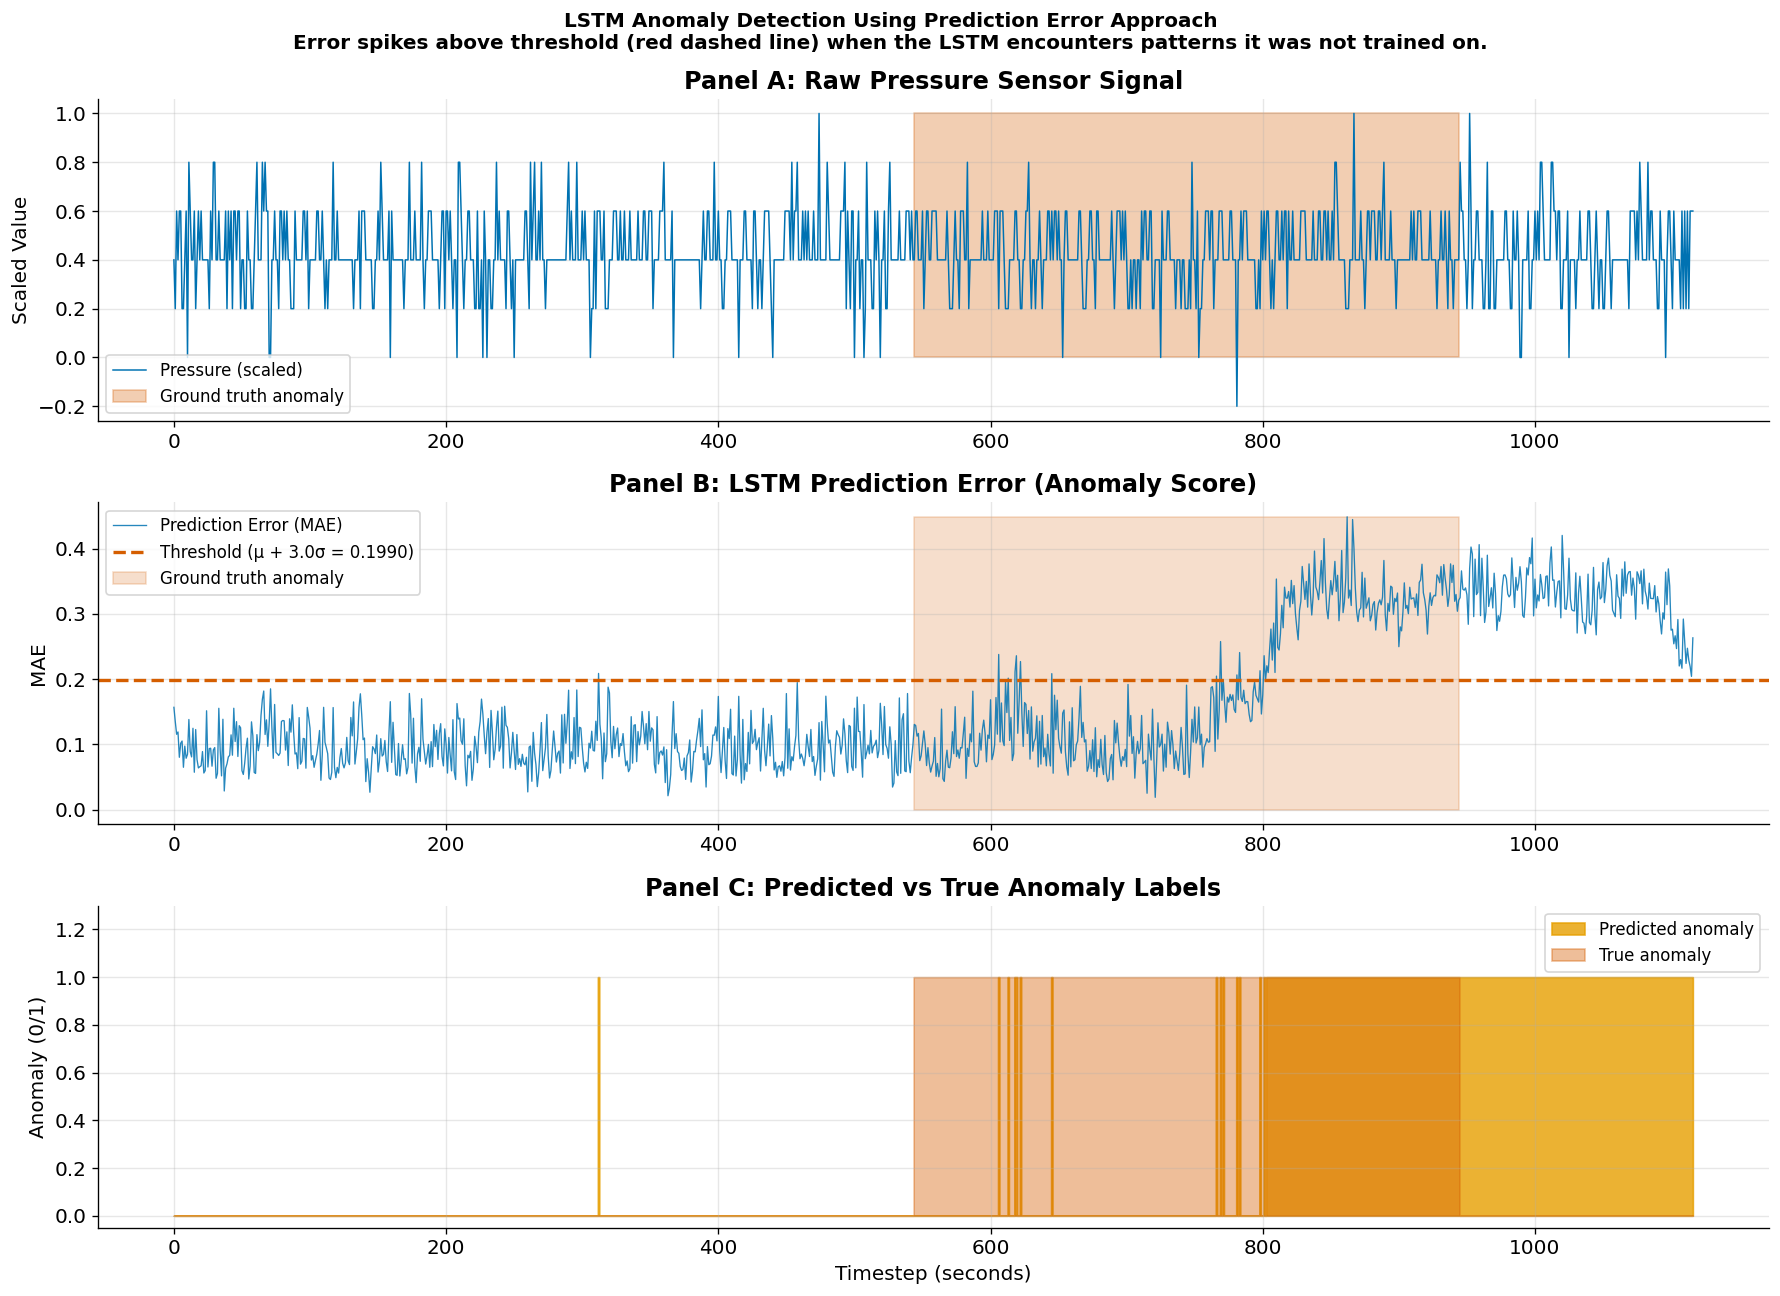

In [ ]:
# Figure 7: Anomaly Score Over Time
# The core teaching figure — shows the prediction error spiking at anomaly windows

time_test = np.arange(len(test_mae))

fig, axes = plt.subplots(3, 1, figsize=(15, 11))

# Panel 1: Raw Pressure signal with anomaly windows
pressure_idx = SENSOR_COLS.index('Pressure')
raw_pressure  = test_scaled[WINDOW_SIZE:, pressure_idx]

axes[0].plot(time_test, raw_pressure,
             color=CB['blue'], linewidth=0.9, label='Pressure (scaled)')
axes[0].fill_between(time_test, 0, 1,
                     where=(test_labels == 1),
                     alpha=0.3, color=CB['red'],
                     label='Ground truth anomaly')
axes[0].set_title('Panel A: Raw Pressure Sensor Signal', fontweight='bold')
axes[0].set_ylabel('Scaled Value')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Panel 2: Prediction error (anomaly score) over time
axes[1].plot(time_test, test_mae,
             color=CB['blue'], linewidth=0.8, alpha=0.85,
             label='Prediction Error (MAE)')
axes[1].axhline(THRESHOLD, color=CB['red'], linewidth=2.0,
                linestyle='--', label=f'Threshold (μ + {K}σ = {THRESHOLD:.4f})')
axes[1].fill_between(time_test, 0, test_mae.max(),
                     where=(test_labels == 1),
                     alpha=0.2, color=CB['red'],
                     label='Ground truth anomaly')
axes[1].set_title('Panel B: LSTM Prediction Error (Anomaly Score)',
                  fontweight='bold')
axes[1].set_ylabel('MAE')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# Panel 3: Binary anomaly detections over time
axes[2].fill_between(time_test, 0, y_pred_binary,
                     step='mid', alpha=0.8,
                     color=CB['orange'], label='Predicted anomaly')
axes[2].fill_between(time_test, 0, test_labels,
                     step='mid', alpha=0.4,
                     color=CB['red'], label='True anomaly')
axes[2].set_title('Panel C: Predicted vs True Anomaly Labels',
                  fontweight='bold')
axes[2].set_xlabel('Timestep (seconds)')
axes[2].set_ylabel('Anomaly (0/1)')
axes[2].set_ylim(-0.05, 1.3)
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

fig.suptitle('LSTM Anomaly Detection Using Prediction Error Approach\n'
             'Error spikes above threshold (red dashed line) when the LSTM '
             'encounters patterns it was not trained on.',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig7_anomaly_scores.png', bbox_inches='tight', dpi=120)
plt.show()


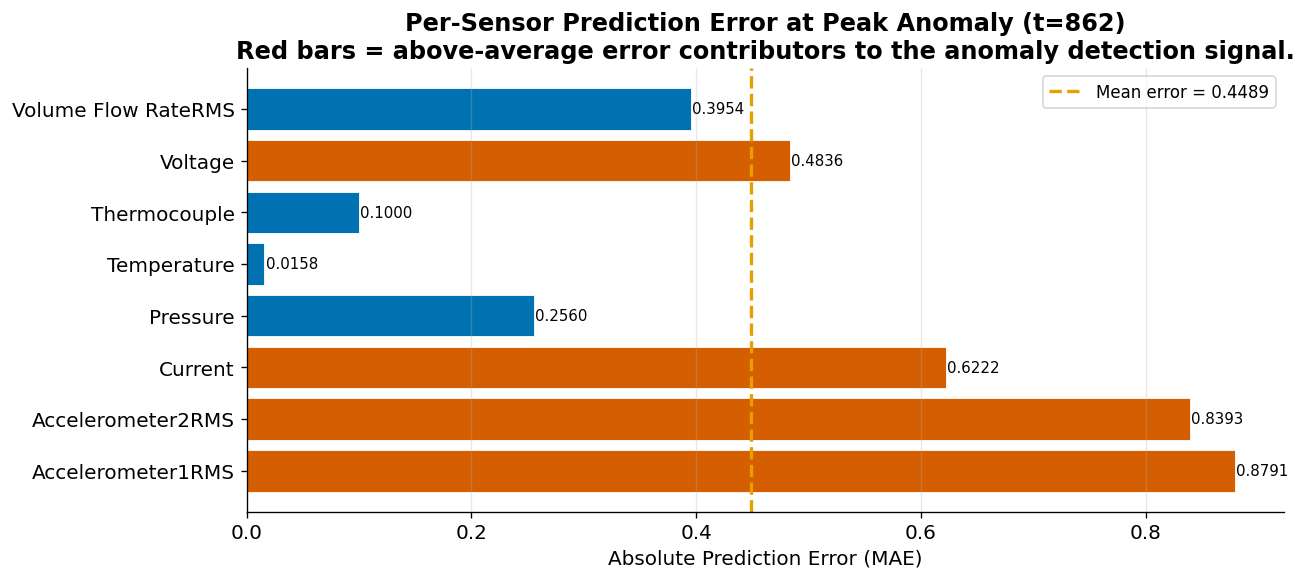


Most informative sensor: Accelerometer1RMS
Least informative sensor: Temperature


In [ ]:
# Figure 8: Per-Sensor Prediction Error at an Anomaly Window
# Which sensors drive the anomaly signal?
# This teaches the reader that not all sensors are equally informative.
# Find the timestep with the highest prediction error
peak_t = np.argmax(test_mae)

per_sensor_error = np.abs(y_test[peak_t] - y_test_pred[peak_t])

fig, ax = plt.subplots(figsize=(11, 5))

bars = ax.barh(SENSOR_COLS, per_sensor_error,
               color=[CB['red'] if e > per_sensor_error.mean() else CB['blue']
                      for e in per_sensor_error],
               edgecolor='white', linewidth=0.5)

ax.axvline(per_sensor_error.mean(), color=CB['orange'],
           linewidth=2, linestyle='--',
           label=f'Mean error = {per_sensor_error.mean():.4f}')

for bar, val in zip(bars, per_sensor_error):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

ax.set_title(f'Per-Sensor Prediction Error at Peak Anomaly (t={peak_t})\n'
             'Red bars = above-average error contributors to the anomaly detection signal.',
             fontweight='bold')
ax.set_xlabel('Absolute Prediction Error (MAE)')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('fig8_per_sensor_error.png', bbox_inches='tight', dpi=120)
plt.show()
print(f'\nMost informative sensor: {SENSOR_COLS[np.argmax(per_sensor_error)]}')
print(f'Least informative sensor: {SENSOR_COLS[np.argmin(per_sensor_error)]}')

---
## Section 8: Evaluation and Critical Analysis

### 8.1 Evaluation Metrics for Anomaly Detection

Standard accuracy is misleading for anomaly detection because anomalies are rare a model that always predicts *normal* would score 95%+ accuracy on most datasets while detecting zero anomalies. We use three metrics instead:

| Metric | Formula | What it measures |
|---|---|---|
| **Precision** | TP / (TP + FP) | Of all timesteps flagged as anomalies, what fraction were real? |
| **Recall** | TP / (TP + FN) | Of all true anomaly timesteps, what fraction did we detect? |
| **F1-Score** | 2 × (P × R) / (P + R) | Harmonic mean  balances precision and recall |

**In industrial safety contexts**, recall is usually more critical than precision. Missing a real fault (false negative) can be catastrophic. A false alarm (false positive) is inconvenient but rarely dangerous.

### 8.2 Threshold Sensitivity

The threshold multiplier $k$ controls the precision-recall tradeoff:
- **Small $k$** → lower threshold → more flagged anomalies → higher recall, lower precision
- **Large $k$** → higher threshold → fewer flagged anomalies → higher precision, lower recall

There is no universally correct $k$  it depends on the cost of false positives vs false negatives in your specific application.

In [ ]:
# Core evaluation metrics
prec   = precision_score(test_labels, y_pred_binary, zero_division=0)
rec    = recall_score(test_labels, y_pred_binary, zero_division=0)
f1     = f1_score(test_labels, y_pred_binary, zero_division=0)
cm     = confusion_matrix(test_labels, y_pred_binary)

print('** Anomaly Detection Results (k=3 threshold) **********************')
print(f'  Precision   : {prec:.4f}  (of flagged anomalies, fraction that are real)')
print(f'  Recall      : {rec:.4f}  (of real anomalies, fraction we detected)')
print(f'  F1-Score    : {f1:.4f}')
print(f'\nConfusion Matrix:')
print(f'  TN={cm[0,0]:,}  FP={cm[0,1]:,}')
print(f'  FN={cm[1,0]:,}  TP={cm[1,1]:,}')
print(f'\nFull classification report:')
print(classification_report(test_labels, y_pred_binary,
                             target_names=['Normal', 'Anomaly']))

** Anomaly Detection Results (k=3 threshold) **********************
  Precision   : 0.4726  (of flagged anomalies, fraction that are real)
  Recall      : 0.3865  (of real anomalies, fraction we detected)
  F1-Score    : 0.4252

Confusion Matrix:
  TN=543  FP=173
  FN=246  TP=155

Full classification report:
              precision    recall  f1-score   support

      Normal       0.69      0.76      0.72       716
     Anomaly       0.47      0.39      0.43       401

    accuracy                           0.62      1117
   macro avg       0.58      0.57      0.57      1117
weighted avg       0.61      0.62      0.62      1117



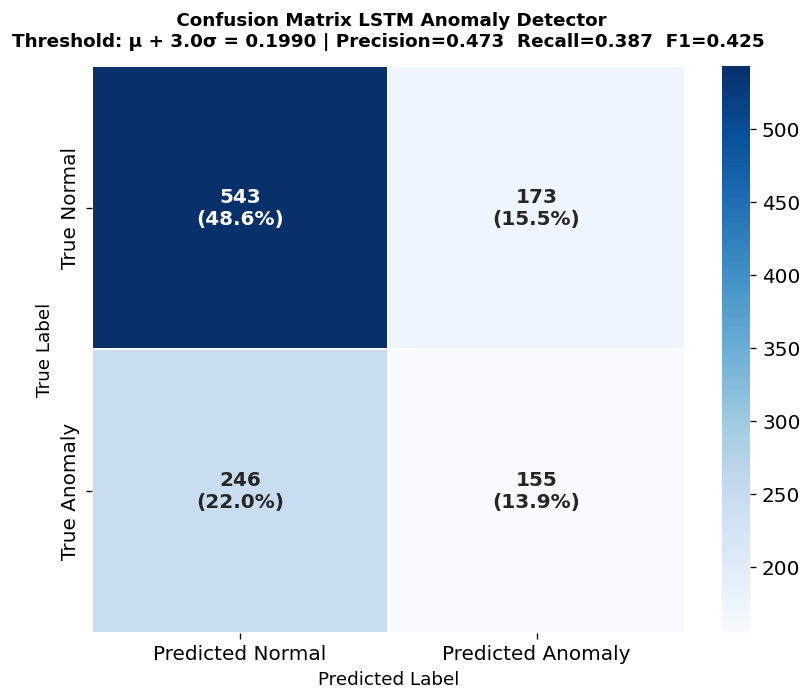

In [ ]:
# Figure 9: Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 6))

# Annotate with both counts and percentages
total = cm.sum()
annot = np.array([[f'{v}\n({v/total*100:.1f}%)' for v in row] for row in cm])

sns.heatmap(
    cm, annot=annot, fmt='', cmap='Blues',
    xticklabels=['Predicted Normal', 'Predicted Anomaly'],
    yticklabels=['True Normal', 'True Anomaly'],
    ax=ax, linewidths=1, linecolor='white',
    annot_kws={'size': 12, 'fontweight': 'bold'}
)
ax.set_title(
    f' Confusion Matrix LSTM Anomaly Detector\n'
    f'Threshold: μ + {K}σ = {THRESHOLD:.4f} | '
    f'Precision={prec:.3f}  Recall={rec:.3f}  F1={f1:.3f}',
    fontsize=11, fontweight='bold', pad=12
)
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)

plt.tight_layout()
plt.savefig('fig9_confusion_matrix.png', bbox_inches='tight', dpi=120)
plt.show()

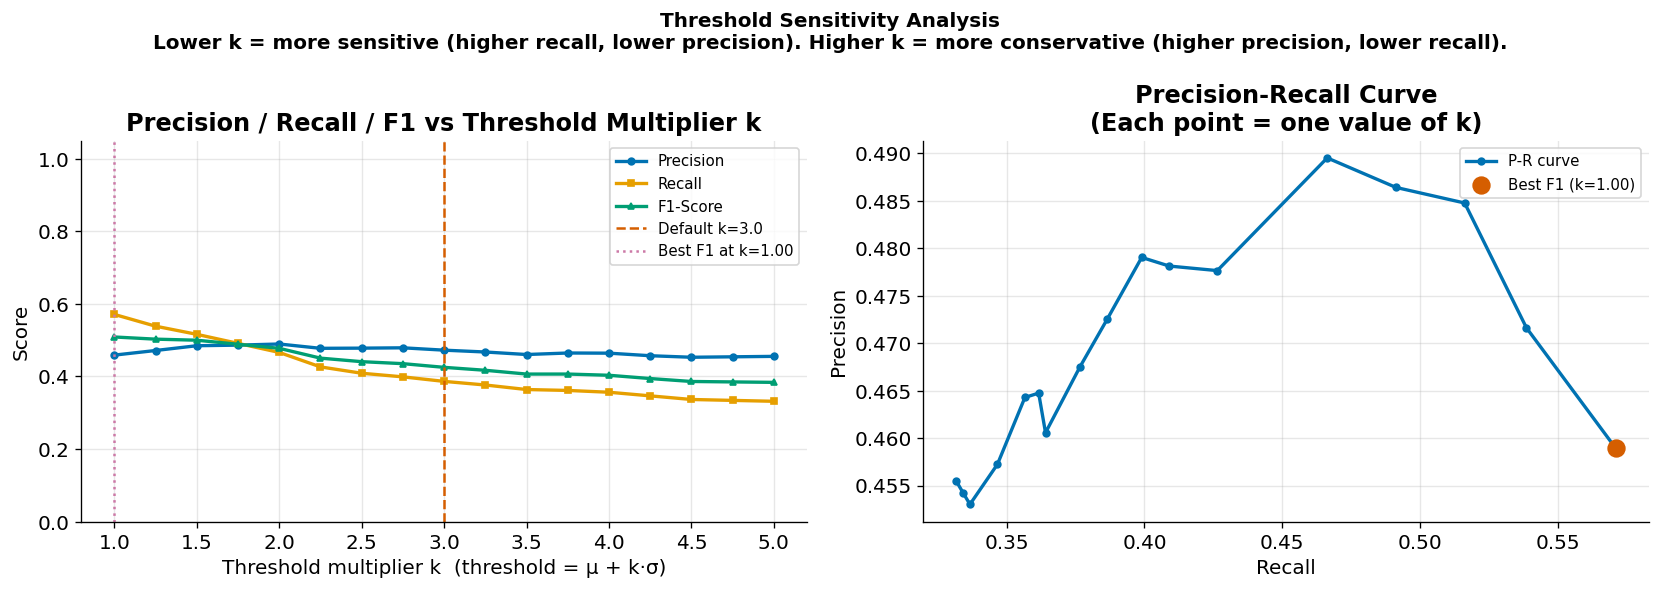

Best F1-Score    : 0.5089  at k=1.00
Default (k=3.0) F1: 0.4252


In [ ]:
# Figure 10: Threshold Sensitivity Analysis
# Critical analysis: how does the choice of k affect Precision, Recall, F1?
# This is the postgraduate-level insight — understanding the precision-recall tradeoff.

k_values  = np.arange(1.0, 5.1, 0.25)
precisions, recalls, f1s, thresholds = [], [], [], []

for k in k_values:
    thresh   = mu_train + k * sigma_train
    y_pred_k = (test_mae > thresh).astype(int)
    precisions.append(precision_score(test_labels, y_pred_k, zero_division=0))
    recalls.append(recall_score(test_labels, y_pred_k, zero_division=0))
    f1s.append(f1_score(test_labels, y_pred_k, zero_division=0))
    thresholds.append(thresh)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Precision, Recall, F1 vs k
axes[0].plot(k_values, precisions, color=CB['blue'],   linewidth=2, marker='o',
             markersize=4, label='Precision')
axes[0].plot(k_values, recalls,    color=CB['orange'], linewidth=2, marker='s',
             markersize=4, label='Recall')
axes[0].plot(k_values, f1s,        color=CB['green'],  linewidth=2, marker='^',
             markersize=4, label='F1-Score')
axes[0].axvline(K, color=CB['red'], linewidth=1.5, linestyle='--',
                label=f'Default k={K}')
best_k_idx = np.argmax(f1s)
axes[0].axvline(k_values[best_k_idx], color=CB['purple'],
                linewidth=1.5, linestyle=':',
                label=f'Best F1 at k={k_values[best_k_idx]:.2f}')
axes[0].set_title('Precision / Recall / F1 vs Threshold Multiplier k',
                  fontweight='bold')
axes[0].set_xlabel('Threshold multiplier k  (threshold = μ + k·σ)')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.05)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Right: Precision-Recall curve
axes[1].plot(recalls, precisions, color=CB['blue'], linewidth=2, marker='o',
             markersize=4, label='P-R curve')
axes[1].scatter([recalls[best_k_idx]], [precisions[best_k_idx]],
                color=CB['red'], s=100, zorder=5,
                label=f'Best F1 (k={k_values[best_k_idx]:.2f})')
axes[1].set_title('Precision-Recall Curve\n'
                  '(Each point = one value of k)',
                  fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

fig.suptitle('Threshold Sensitivity Analysis\n'
             'Lower k = more sensitive (higher recall, lower precision). '
             'Higher k = more conservative (higher precision, lower recall).',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig10_threshold_sensitivity.png', bbox_inches='tight', dpi=120)
plt.show()

print(f'Best F1-Score    : {max(f1s):.4f}  at k={k_values[best_k_idx]:.2f}')
print(f'Default (k={K}) F1: {f1:.4f}')


---
## Section 9: Practical Recommendations, Limitations & Ethics

### 9.1 Practical Recommendations

Based on the results of this tutorial, the following guidelines apply when using LSTM-based anomaly detection in practice:

**Always train on normal data only.**  
The key assumption of prediction-error anomaly detection is that the model has never seen an anomaly. If anomaly windows are included in training, the model will learn to predict them and the error signal will be suppressed. In practice, filter your training data to known-good operational periods.

**Fit the scaler and threshold on training data only.**  
Any parameter derived from the full dataset (including test/live data) introduces data leakage. The MinMaxScaler and the threshold (μ + kσ) must both be computed solely from the training set, then applied to new data.

**Tune k to match your application's risk tolerance.**  
As shown in Figure 10, there is no universally optimal k. In safety-critical applications (e.g., medical equipment, power grids), maximise Recall even at the cost of more false alarms. In maintenance scheduling (e.g., factory equipment), a higher k reduces unnecessary inspection costs.

**Monitor sensor-level errors, not just aggregate MAE.**  
Figure 8 showed that different sensors contribute differently to the anomaly score. Per-sensor error analysis can reveal which physical subsystem is failing a vibration anomaly indicates a mechanical fault; a current anomaly points to an electrical issue. Aggregate MAE loses this diagnostic information.

**Expect degradation on unseen anomaly types.**  
The model was trained on one experiment file. Anomaly types not represented in the training distribution (e.g., a type of fault that produces a different signal pattern) may not generate sufficient prediction error to exceed the threshold. This is a known limitation of prediction-based approaches.

### 9.2 Limitations of This Approach

No method is perfect. The LSTM prediction-error approach has specific failure modes:

1. **Slowly drifting anomalies** : If the anomaly develops gradually over many timesteps, the LSTM may adapt its predictions to follow the drift, suppressing the error signal. This is called *concept drift*.
2. **Anomalies similar to normal patterns**: A fault that produces sensor values within the normal operating range but in an unusual combination may not generate sufficient prediction error.
3. **Threshold rigidity**: A static threshold assumes the normal error distribution is stationary. In systems where the normal operating condition changes (e.g., seasonal variation in a water system), the threshold must be updated regularly.
4. **Multivariate dependency**: Using aggregate MAE across sensors treats each sensor as equally important. A weighted MAE (or per-sensor threshold) would be more robust.

### 9.3 Ethical Considerations

Automated anomaly detection systems in industrial and public infrastructure carry non-trivial ethical responsibilities:

**Worker safety and accountability**: When an LSTM-based system misses a fault (false negative) and equipment subsequently fails, it raises questions of accountability. Was the system adequately validated before deployment? Were its known failure modes communicated to operators? Deploying any automated safety-critical system without transparent documentation of its limitations is ethically indefensible.

**Over-reliance and deskilling**: Operators who rely heavily on automated anomaly detectors may lose the skill to identify anomalies manually. If the system fails (e.g., due to sensor drift that shifts the error distribution), human oversight may no longer be sufficient. Anomaly detection systems should augment, not replace, human expertise.

**Privacy in workplace monitoring**: Sensor data from industrial environments can reveal worker behaviour patterns indirectly. In settings where sensors are attached to equipment operated by specific individuals, continuous monitoring can constitute surveillance. Data governance policies and consent mechanisms must be in place before deploying such systems.

**Fairness in infrastructure**: Anomaly detection systems trained on data from well-maintained, high-income facilities may perform poorly when deployed in under-resourced settings with older equipment producing different signal characteristics. Care must be taken not to create a two-tier system where safety-critical anomalies are reliably detected in some facilities but missed in others.

---
## Section 10: Conclusion

This tutorial has demonstrated end-to-end LSTM-based anomaly detection on real industrial sensor data. The key findings and lessons are:

| Component | Key Lesson |
|---|---|
| **Vanishing gradient problem** | Vanilla RNNs cannot learn long-range temporal dependencies the product of small gradients across many timesteps approaches zero |
| **LSTM gates** | The forget, input, cell-update, and output gates updated through addition in the cell state preserve gradient flow and enable learning over 30+ timestep windows |
| **Train on normal only** | The anomaly detection strategy relies on the LSTM never having seen an anomaly prediction error spikes precisely because the pattern is unfamiliar |
| **Threshold (μ + kσ)** | A statistically grounded threshold, computed on training errors only, provides a principled anomaly decision boundary without requiring labelled anomaly data during training |
| **Precision-Recall tradeoff** | There is no universal best threshold — the optimal k depends on the relative cost of false positives vs false negatives in the deployment context |
| **Per-sensor error** | Aggregate MAE provides the anomaly signal; per-sensor decomposition provides the diagnostic signal which subsystem is failing |

The pipeline demonstrated here normalise on train, build sliding windows, train LSTM on normal data, threshold the prediction error generalises to any multivariate time-series anomaly detection problem: server telemetry, electrocardiogram monitoring, power grid fault detection, or financial transaction streams.

---
## References

1. Hochreiter, S., & Schmidhuber, J. (1997). Long Short-Term Memory. *Neural Computation*, 9(8), 1735–1780. https://doi.org/10.1162/neco.1997.9.8.1735
2. Katser, I. D., & Kozitsin, V. O. (2020). Skoltech Anomaly Benchmark (SKAB). *Kaggle*. https://doi.org/10.34740/KAGGLE/DSV/1693952
3. Malhotra, P., Vig, L., Shroff, G., & Agarwal, P. (2015). Long Short Term Memory Networks for Anomaly Detection in Time Series. *ESANN 2015*, 89–94.
4. Chollet, F. (2021). *Deep Learning with Python* (2nd ed.). Manning Publications.
5. Kingma, D. P., & Ba, J. (2014). Adam: A Method for Stochastic Optimization. *arXiv:1412.6980*.
6. Srivastava, N., Hinton, G., Krizhevsky, A., Sutskever, I., & Salakhutdinov, R. (2014). Dropout: A Simple Way to Prevent Neural Networks from Overfitting. *JMLR*, 15, 1929–1958.
7. Keras Documentation (2024). https://keras.io/
8. Scikit-learn Documentation (2024). https://scikit-learn.org/

---
*GitHub: https://github.com/mh25afc/LSTM_SKAB_AnomalyDetection*  
*All figures use the Wong (2011) colourblind-safe palette. Verified against deuteranopia, protanopia, and tritanopia simulations.*  
*Dataset: SKAB v0.9 — Katser & Kozitsin (2020). Kaggle DOI: 10.34740/KAGGLE/DSV/1693952*